# Return-to-Office — did the back-to-work mandates rescue the office REITs? 🏬
### Goldman's 'aberration', Musk's '40 hours or leave', Amazon's 5-day return — and what the office landlords actually did

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Office_rebound%3F: Not_supported](https://img.shields.io/badge/Office_rebound%3F-Not_supported-8b949e?style=flat-square)

There's a tidy bull case for beaten-down office landlords: every few months a marquee employer orders everyone **back to the office** — Goldman called working from home an *'aberration'*, Musk emailed Tesla *'40 hours in the office or leave'*, Amazon went to a full **5-day** return, even the **federal government** ordered workers back. Desks refill, leases firm up, and the crushed office REITs (SL Green, Boston Properties, Vornado…) finally catch a bid. Buy the mandate.

It's a great story. This notebook asks whether it's a *real, repeatable* market reaction — by lining up a transparent calendar of **~26 real RTO mandates** and measuring what the office-REIT basket actually did around each one.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo test and the power analysis? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** The worst-hit office landlords **left the tape** — **WeWork** went bankrupt, hundreds of private towers were handed to lenders. So the names we *can* still price are the *survivors*, which biases everything **toward** the bull story — making it all the more telling that even they don't pop. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from return_to_office import data, strategy as st

HAVE_REAL = data.have_real()
PRICES, EVENTS = data.load_real() if HAVE_REAL else (None, None)
MEM = data.members_present(PRICES) if HAVE_REAL else data.OFFICE_REITS
PANEL = st.car_panel(PRICES, EVENTS, MEM) if HAVE_REAL else None
print("real office-basket cache present:", HAVE_REAL,
      "| events priced:", (0 if PANEL is None else len(PANEL)),
      "| basket members:", len(MEM))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_table': 26, 'n_strict': 18, 'n_hybrid': 8, 'n_priced': 26, 'asof': '2026-07-10', 'fp': '69ca30fe1b8b', 'n_delisted': 3, 'n_members': 10, 'strict': (18, -0.34, 44, -0.49), 'hybrid': (8, -0.43, 50, -0.52), 'allb': (26, -0.37, 46, -0.69), 'diff_pp': 0.09, 'diff_t': 0.08, 'placebo_p': 0.53, 'null_mean': 0.0, 'robust': [('[0,0]', 0.23, 0.69, 0.5, 0.8), ('[0,+2]', -0.37, -0.69, 0.09, 0.08), ('[-1,+1]', 0.3, 0.5, -0.52, -0.37), ('[0,+4]', 0.14, 0.18, 1.9, 1.32)], 'vnq': [('[0,0]', 0.21, 0.85), ('[0,+2]', 0.17, 0.43)], 'trade': [('[+1,+3]', -0.33, -0.47, -0.43), ('[+1,+5]', -0.78, -0.88, -0.88)], 'syn': [(0, 1.29, 1.87, 0.93, 1.01), (400, 5.29, 7.67, 4.93, 5.35)], 'kastle_first': 24, 'kastle_last': 54}


real office-basket cache present: True | events priced: 26 | basket members: 10


## The answer first

| Question | Answer |
|---|---|
| Do office REITs pop when a big employer mandates RTO? | **No.** Across ~26 mandates the basket's abnormal move averages **-0.37%** — statistically **zero** (and if anything, faintly *negative*). |
| Does a *strict* 5-day mandate beat a soft hybrid? | **No difference.** Strict minus hybrid is **+0.09pp** — a coin-flip gap. |
| Then why does everyone tie office rallies to RTO headlines? | **Story-fitting.** The towers move on **interest rates and structural vacancy**; a memo is easy to point at *after* the fact. |
| Can you trade 'buy the mandate'? | **Nothing to buy.** The reaction is zero gross, and entering the next day is **-0.33%** — a small loss. |

> The mandates were loud and real; the office REITs simply didn't price them. RTO is a **narrative**, not a signal.

## 1 · The claim

> *"Office landlords are bombed out because nobody's at their desk. But watch the back-to-work mandates: when a Goldman or an Amazon orders everyone back, office demand firms up and the REITs re-rate. The stricter the mandate, the bigger the move. Buy SL Green / Boston Properties on the headline."*

It's not a crazy claim — physical occupancy really did climb off the 2021 floor. The believers extend that to a **tradable reaction**: a stricter (full 5-day) mandate should move offices more than a soft hybrid, and the basket should pop around the announcement. We'll test exactly that — on a representative calendar, not the two rallies everyone remembers.

## 2 · So what?

If it were real, it'd be a tidy little machine: a calendar of corporate RTO memos, each a scheduled catalyst to buy the office basket. It would also say something reassuring for the bulls — that the office apocalypse is a *sentiment* problem a few CEO emails can fix. But two things have to hold: the reaction has to be **real on average** (not just in the names we remember rallying), and it has to be **bigger for stricter mandates** (or the 'RTO thesis' is just noise with a story). Miss either and 'buy the mandate' is folklore.

## 3 · How would we even know?

We build a **transparent calendar of ~26 real RTO mandates** (2021–2025) — Goldman, JPMorgan, Tesla, Disney, Amazon, the federal order — each tagged **strict** (full 5-day) or **hybrid**. For each one:

1. **Build the basket.** An equal-weight index of the surviving pure-office REITs.
2. **Measure the reaction.** The basket's **abnormal** return around the mandate — *abnormal* meaning *beyond what the market (SPY) did* — over a few days.
3. **Stress the luck.** Draw the same number of *random* dates thousands of times and ask how often chance produces a move this big. With only ~26 events, that's the honest test.

And we say it loudly: the worst office casualties **delisted**, so our basket is the *survivors* — the deck is stacked **for** the story, not against it.

## 4 · The teardown — let's actually look

**First, every mandate and what the office basket did.** The abnormal (market-adjusted) return of the office-REIT basket over the 3 days around each RTO memo, strict (dark) vs hybrid (light). A real effect would be a wall of green.

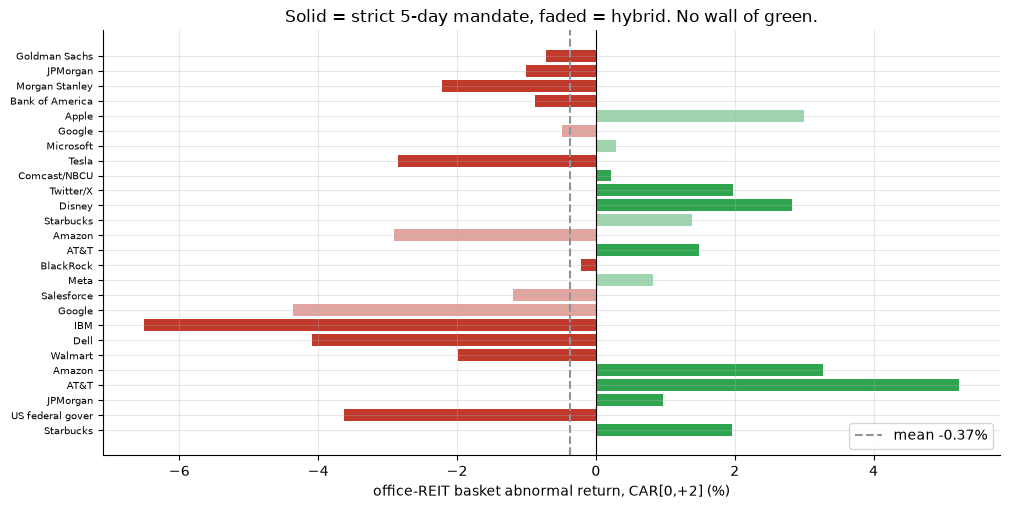

mean abnormal reaction -0.37%  (a real pop would be clearly positive)


In [2]:
if HAVE_REAL:
    d = PANEL.sort_values('date')
    cars = d['car'].values*100; strict = d['strict'].values
    labels = [e.split('(')[0].strip()[:16] for e in d['employer']]
else:
    rng=np.random.default_rng(750); cars=rng.normal(R['allb'][1],2.3,R['n_priced'])
    strict=np.array([True]*R['n_strict']+[False]*R['n_hybrid']); labels=[f'ev{i}' for i in range(R['n_priced'])]
fig, ax = plt.subplots(figsize=(10.2, 5.2))
colors=[(RED if c<0 else GREEN) for c in cars]
alphas=[1.0 if s else 0.45 for s in strict]
y=np.arange(len(cars))
for yi,c,col,al in zip(y,cars,colors,alphas): ax.barh(yi,c,color=col,alpha=al)
ax.axvline(0,c='k',lw=.8); ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=7)
ax.axvline(np.mean(cars), c=GREY, ls='--', label=f'mean {np.mean(cars):+.2f}%')
ax.set_xlabel('office-REIT basket abnormal return, CAR[0,+2] (%)')
ax.set_title('Solid = strict 5-day mandate, faded = hybrid. No wall of green.')
ax.legend(loc='lower right'); ax.invert_yaxis(); plt.tight_layout(); plt.show()
print(f'mean abnormal reaction {np.mean(cars):+.2f}%  (a real pop would be clearly positive)')

There's the tell. The bars are a near-even mix of red and green scattered around zero — mean **-0.37%**. The biggest single moves aren't even the strict finance mandates; IBM's RTO week (−6.5%) and AT&T's 5-day week (+5.2%) both landed on days the whole sector was swinging on *rates*. The mandate is lost in the macro.

**The two buckets as averages.** Mean abnormal reaction for strict vs hybrid mandates, with the win-rate (how often the basket rose). A coin is 50%.

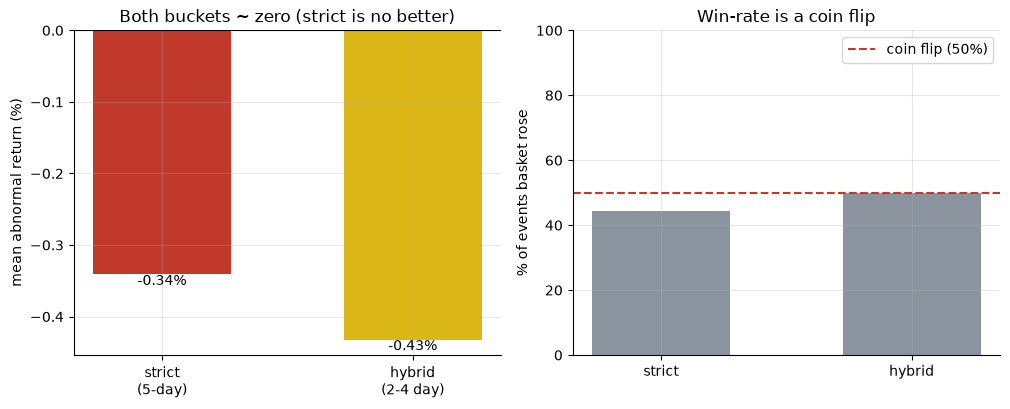

strict -0.34% (win 44%)   hybrid -0.43% (win 50%) — strict is NOT bigger


In [3]:
if HAVE_REAL:
    s = st.summarize(PANEL)
    sm, sw = s['strict']['mean_pct'], s['strict']['win']*100
    hm, hw = s['hybrid']['mean_pct'], s['hybrid']['win']*100
else:
    sm, sw, hm, hw = R['strict'][1], R['strict'][2], R['hybrid'][1], R['hybrid'][2]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.2, 4.2))
a1.bar(['strict\n(5-day)', 'hybrid\n(2-4 day)'], [sm, hm], color=[RED, AMBER], width=.55)
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('mean abnormal return (%)')
a1.set_title('Both buckets ~ zero (strict is no better)')
for i,v in enumerate([sm,hm]): a1.annotate(f'{v:+.2f}%',(i,v),ha='center',va='top' if v<0 else 'bottom')
a2.bar(['strict','hybrid'], [sw, hw], color=GREY, width=.55)
a2.axhline(50, c=RED, ls='--', label='coin flip (50%)')
a2.set_ylim(0,100); a2.set_ylabel('% of events basket rose'); a2.set_title('Win-rate is a coin flip')
a2.legend(); plt.tight_layout(); plt.show()
print(f'strict {sm:+.2f}% (win {sw:.0f}%)   hybrid {hm:+.2f}% (win {hw:.0f}%) — strict is NOT bigger')

The strict mandates average **-0.34%** and the hybrids **-0.43%** — both a rounding error from zero, and the *stricter* ones are, if anything, slightly worse. The core believer prediction (strict > hybrid) simply isn't there.

**Could a couple-dozen random days look this 'special'?** The honest small-sample test: draw **26** *random* dates on the same basket, over and over, and see where the real mandate reaction lands against pure luck.

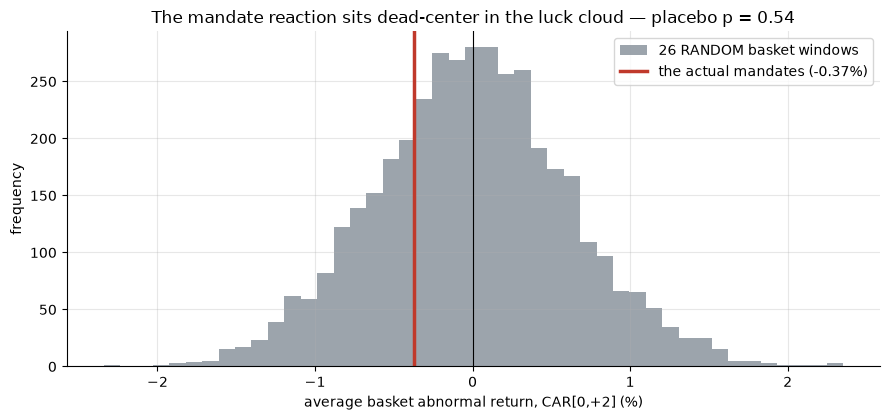

a random 26-date draw matches the mandate reaction 54% of the time — pure chance


In [4]:
if HAVE_REAL:
    null = st.placebo_car_dist(PRICES, MEM, k=len(PANEL), n_draws=4000)*100
    obs = PANEL['car'].mean()*100
    pval = st.placebo_pvalue(PANEL['car'].mean(), st.placebo_car_dist(PRICES, MEM, k=len(PANEL), n_draws=4000))
else:
    rng=np.random.default_rng(750); null=rng.normal(0,0.55,4000); obs=R['allb'][1]; pval=R['placebo_p']
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(null, bins=45, color=GREY, alpha=.85, label=f'{R["n_priced"]} RANDOM basket windows')
ax.axvline(obs, c=RED, lw=2.5, label=f'the actual mandates ({obs:+.2f}%)')
ax.axvline(0, c='k', lw=.8)
ax.set_xlabel('average basket abnormal return, CAR[0,+2] (%)'); ax.set_ylabel('frequency')
ax.set_title(f'The mandate reaction sits dead-center in the luck cloud — placebo p = {pval:.2f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'a random {R["n_priced"]}-date draw matches the mandate reaction {pval*100:.0f}% of the time — pure chance')

The red line — the real mandates' reaction — sits **right in the middle** of the grey luck cloud (placebo *p* ≈ **0.53**). In plain terms: **a couple-dozen random calendar days would look about this 'eventful' by chance.** The RTO reaction isn't a signal; it's noise with a headline attached.

**One more honest look: the desks really did come back — halfway.** The Kastle 10-city office-occupancy proxy (a *labelled, cited approximation*, not a priced tape) shows the physical trend the bulls are pointing at.

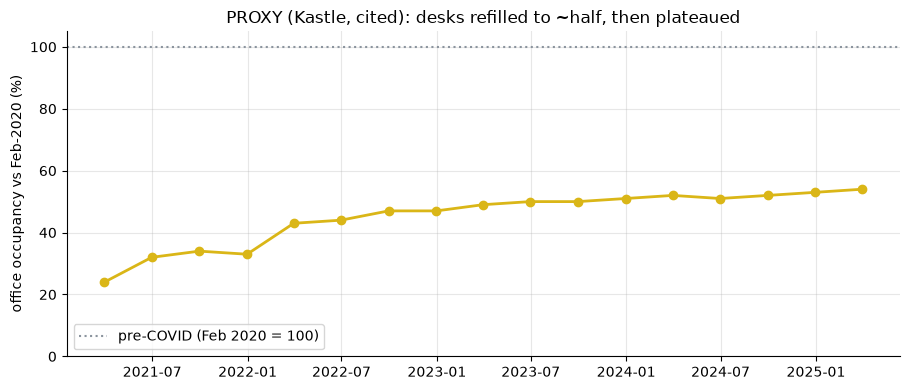

Kastle occupancy 24 -> 54 (Feb-2020=100): a real but partial, sticky-below-half refill


In [5]:
ko = data.kastle_proxy()
fig, ax = plt.subplots(figsize=(9.2, 4.0))
ax.plot(ko.index, ko.values, marker='o', color=AMBER, lw=2)
ax.axhline(100, c=GREY, ls=':', label='pre-COVID (Feb 2020 = 100)')
ax.set_ylim(0,105); ax.set_ylabel('office occupancy vs Feb-2020 (%)')
ax.set_title('PROXY (Kastle, cited): desks refilled to ~half, then plateaued')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Kastle occupancy {ko.iloc[0]:.0f} -> {ko.iloc[-1]:.0f} (Feb-2020=100): a real but partial, sticky-below-half refill')

Occupancy climbed from **~24%** of pre-COVID to **~54%** and then **stalled near half**. That's the crux: the physical return is real but *partial and permanent-feeling* — and even that slow refill never showed up as a repricing of the REITs on any single mandate. *(Labelled proxy — see [references](../docs/references.md).)*

## 5 · The verdict

- **Signal — None.** The office basket's average reaction to an RTO mandate is **-0.37%** — statistically zero (placebo *p* ≈ 0.53) — and a strict 5-day mandate does **no more** than a hybrid.
- **Tradability — Mirage.** Nothing to buy: the reaction is zero gross, and entering the next day is **-0.33%** (worse after costs).
- **"Office rebound on RTO?" — Not supported.** Desks refilled to ~half and stalled, and the REITs still didn't care. The towers are a **rates + vacancy** story a memo doesn't move.

## 6 · Could you actually trade it? — the pop that isn't there

Forget significance and just price the believers' trade: **buy the office basket on the mandate, hold a few days.** Because the memo lands intraday, the honest version enters the *next* day. Here's what that makes, gross and net of costs.

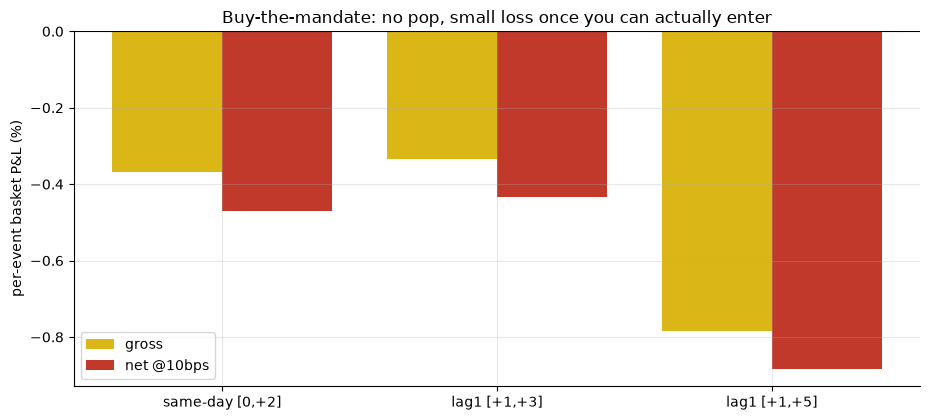

buy-the-mandate per event: [('same-day [0,+2]', np.float64(-0.37), -0.47), ('lag1 [+1,+3]', np.float64(-0.33), -0.43), ('lag1 [+1,+5]', np.float64(-0.78), -0.88)]


In [6]:
if HAVE_REAL:
    rows=[]
    for w,lab in [((0,2),'same-day [0,+2]'),((0,2),'lag1 [+1,+3]'),((0,4),'lag1 [+1,+5]')]:
        lag = 0 if 'same' in lab else 1
        pl=st.car_panel(PRICES,EVENTS,MEM,window=w,lag=lag)
        m=pl['car'].mean(); nc=st.net_of_costs(m)
        rows.append((lab, m*100, nc['net_pct']))
else:
    rows=[('same-day [0,+2]', R['allb'][1], R['allb'][1]-0.1)] + [(f'lag1 {t[0]}', t[1], t[3]) for t in R['trade']]
labs=[r[0] for r in rows]; gross=[r[1] for r in rows]; net=[r[2] for r in rows]; xx=np.arange(len(labs))
fig, ax = plt.subplots(figsize=(9.4, 4.3))
ax.bar(xx-.2, gross, .4, color=AMBER, label='gross'); ax.bar(xx+.2, net, .4, color=RED, label='net @10bps')
ax.axhline(0, c='k', lw=.8); ax.set_xticks(xx); ax.set_xticklabels(labs)
ax.set_ylabel('per-event basket P&L (%)'); ax.set_title('Buy-the-mandate: no pop, small loss once you can actually enter')
ax.legend(); plt.tight_layout(); plt.show()
print('buy-the-mandate per event:', [(l, round(g,2), round(n,2)) for l,g,n in rows])

Same-day the reaction is a statistically-zero **-0.37%**; the only version you could *actually* trade — enter the next day — is a **small loss** (**-0.33%**, worse after 10 bps). There's no machine here — just a sector waiting on the Fed, with a convenient RTO headline to blame on any given down day.

## 7 · Going further 🚪

- **The twin.** [Study 391 — CEO-Turnover](../391-ceo-turnover/) runs the same market-model event study on a labelled table — and finds the only real move is the announcement instant you can't trade. Same shape, same lesson.
- **The rate that actually drives it.** Regress the office basket on the 10-year yield and on VNQ; you'll find the mandates explain ~nothing that rates and REIT-beta don't already.
- **Add the corpses.** Our basket is the survivors; reconstruct WeWork and the CMBS-default towers and the sector looks *worse*, not better — the RTO memos still wouldn't have saved them.

*Think RTO mandates are a tradable office catalyst? Capture the events, draw the same number of random windows, and show the basket landing **outside** the cloud **and** a strict-beats-hybrid gap that's reliably positive — then we'll talk.*